# 3.0 CPA — 프로파일링 없이 키 복구

## 이 노트북이 답하는 질문

**타겟과 똑같은 장비를 미리 확보하지 못한 상태에서 키를 꺼낼 수 있는가?**

`scalib.attacks.Cpa` 는 상관 전력 분석(Correlation Power Analysis)을 수행한다.
프로파일링 단계가 없어 **공격자가 준비할 것이 적다** — 필요한 것은 평문과 파형뿐이다.

| | |
|---|---|
| 입력 | `/attack` (고정 키 · 랜덤 평문 10,000장) |
| 성공 판정 | 데이터셋 attrs 의 정답 키 16바이트를 **전부** 맞히는가 |
| 하드웨어 | 불필요 |

## 원리

키 한 바이트를 $k$ 라 하고 그 값을 256가지로 **추측**한다. 추측 $g$ 마다 중간값을 계산하고,

$$ v_i(g) = \mathrm{SBOX}[\ p_i \oplus g\ ] $$

그 값이 만들 법한 전력을 **누설 모델**로 예측한다(여기서는 해밍 가중치 $\mathrm{HW}(v)$).
그런 다음 시점 $j$ 마다 실제 파형과의 **피어슨 상관계수**를 잰다.

$$ \rho_{g,j} = \mathrm{corr}\big(\ \mathrm{HW}(v_i(g))\ ,\ l_{i,j}\ \big) $$

추측이 맞으면 예측과 실제가 같은 이유로 움직이므로 어느 시점에서 상관이 크게 튄다.
틀리면 S-box 의 비선형성 때문에 예측이 사실상 무작위가 되어 상관이 낮게 깔린다.

**바이트마다 독립으로 256번만 시도**하면 되므로, $2^{128}$ 이 아니라 $16 \times 256$ 번의 계산이다.

## `Cpa` 의 라벨과 모델

`Cpa(nc, kind)` 에서 `kind` 는 라벨과 키 추측을 어떻게 합치는지를 정한다.

| `kind` | 중간값 |
|--------|--------|
| `Cpa.IntermediateKind.Xor` | `label ^ guess` |
| `Cpa.IntermediateKind.Add` | `(label + guess) mod nc` |

즉 **라벨은 평문 바이트**이고, `models[v][j]` 는 "중간값이 $j$ 일 때의 예측 누설" 이다.
우리는 SBox 출력의 해밍 가중치를 노리므로 `models[v][j] = HW[SBOX[j]]` 가 된다.

In [1]:
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

# 공용 정의(AES 상수·데이터셋 로더)는 scalib_common.py 한 곳에만 둔다.
# 노트북마다 복사하면 값을 고칠 곳이 10군데가 되기 때문이다.
sys.path.insert(0, ".")
from scalib_common import SBOX, HW, AES_BLOCK, sbox_out, load_group, dataset_summary

import scalib
print("SCALib :", scalib.__version__)
print()
print(dataset_summary())

SCALib : 0.6.4

측정 조건
  created      2026-08-07T00:34:27
  cipher       AES-128-ECB (tiny-AES-c)
  platform     CW308_STM32F3
  ns           33172
  adc_mul      4
  adc_freq     29537976.0
  clk_hz       7384494.0
  gain_db      25.091743119266056
  trace_scale  32768.0

그룹
  /attack      10000 장 x 33172 샘플   키=fixed 평문=random
  /explore      5000 장 x 33172 샘플   키=random 평문=random
  /profiling    4000 장 x 33172 샘플   키=? 평문=?
  /tvla_fk      1000 장 x 33172 샘플   키=fixed 평문=fixed
  /tvla_rk      1000 장 x 33172 샘플   키=random 평문=fixed


In [2]:
d = load_group("attack")
traces, pt = d["t"], d["p"]
TRUE_KEY = np.array(d["attrs"]["fixed_key"], dtype=np.uint8)
n, ns = traces.shape

print("파형:", traces.shape, " 평문:", pt.shape)
print("키가 고정인가:", len(np.unique(d["k"], axis=0)) == 1)
print("정답 키:", " ".join("%02x" % b for b in TRUE_KEY))
print("(정답을 아는 이유: 이 데이터셋은 교육용이라 attrs 에 기록해 두었다.")
print(" 실제 공격에서는 모르며, 아래 절차는 정답을 전혀 쓰지 않는다.)")

파형: (10000, 33172)  평문: (10000, 16)
키가 고정인가: True
정답 키: 2f 6b 07 31 d3 e2 66 7f 26 85 42 9f 35 dc 5d d1
(정답을 아는 이유: 이 데이터셋은 교육용이라 attrs 에 기록해 두었다.
 실제 공격에서는 모르며, 아래 절차는 정답을 전혀 쓰지 않는다.)


---
## 1. 계산 구간 좁히기

파형 전체(33,172 샘플)로 돌려도 되지만, 1.0 SNR 이 찾아 둔 누설 구간만 보면 훨씬 빠르다.
**공격 자체에는 SNR 이 필요 없다** — 없으면 전 구간을 쓰면 된다.

In [3]:
from pathlib import Path

POI_PATH = Path("nb_output/poi.npz")
if POI_PATH.is_file():
    poi = np.load(POI_PATH)["poi"]
    LO, HI = max(0, int(poi.min()) - 400), min(ns, int(poi.max()) + 400)
    print("1.0 의 POI 를 이용해 구간 [%d, %d) 로 좁힌다 (%d 샘플)" % (LO, HI, HI - LO))
else:
    LO, HI = 0, ns
    print("poi.npz 가 없어 전 구간을 쓴다 (1.0.SNR 을 먼저 실행하면 빨라진다)")

seg = np.ascontiguousarray(traces[:, LO:HI])
print("분석 대상:", seg.shape)

1.0 의 POI 를 이용해 구간 [5645, 7297) 로 좁힌다 (1652 샘플)
분석 대상: (10000, 1652)


---
## 2. `Cpa` 실행

| 단계 | 코드 |
|:----:|------|
| 생성 | `cpa = Cpa(nc=256, kind=Cpa.IntermediateKind.Xor)` |
| 누적 | `cpa.fit_u(traces, labels)` — 라벨은 **평문** `(n, nv)` `uint16` |
| 결과 | `cpa.get_correlation(models)` → `(nv, nc, ns)` |

`models` 는 `(nv, nc, ns)` `float64` 다. 시점마다 다른 모델을 줄 수도 있지만
해밍 가중치 모델은 시점에 무관하므로 같은 값을 브로드캐스트한다.

> **라벨 shape 규약이 API 마다 다르다.** 문서에 정리되어 있지 않고 실행해 봐야 알 수 있어
> 여기 적어 둔다. 틀리면 `ValueError: The classes array has N dimensions` 가 난다.
>
> | API | 라벨 shape | dtype |
> |-----|-----------|-------|
> | `Ttest` | `(n,)` | `uint16` |
> | `SNR`, `Cpa`, `MultiLDA` | `(n, nv)` | `uint16` |
> | `LDAClassifier` | `(n,)` | `uint16` |
> | `RLDAClassifier` | `(n, nv)` | `uint64` |
> | `RLDAInformationEstimator` | `(n,)` | `uint64` |
>
> 파형(`traces`)은 어디서나 `(n, ns)` `int16` 이다.

In [4]:
from scalib.attacks import Cpa
import time

NV = AES_BLOCK
labels = pt.astype(np.uint16)                 # 라벨 = 평문 (알려진 값)

t0 = time.time()
cpa = Cpa(nc=256, kind=Cpa.IntermediateKind.Xor)
cpa.fit_u(seg, labels)

# 누설 모델: 중간값 j (= p^k) 가 S-box 를 지난 뒤의 해밍 가중치
model_1d = HW[SBOX[np.arange(256)]].astype(np.float64)      # (256,)
models = np.broadcast_to(model_1d[None, :, None],
                         (NV, 256, seg.shape[1])).copy()     # (nv, nc, ns)

corr = cpa.get_correlation(models)
print("계산 %.1f 초 → corr %s  (바이트, 키추측, 샘플)" % (time.time() - t0, corr.shape))

계산 0.1 초 → corr (16, 256, 1652)  (바이트, 키추측, 샘플)


---
## 3. 키 복구

바이트마다 "가장 큰 |상관|을 낸 추측" 이 복구한 키다.

In [5]:
absmax = np.nanmax(np.abs(corr), axis=2)        # (16, 256) 추측별 최고 상관
recovered = absmax.argmax(axis=1).astype(np.uint8)
best = absmax.max(axis=1)

# 2등과의 격차. 클수록 확신이 크다.
second = np.sort(absmax, axis=1)[:, -2]
ok = recovered == TRUE_KEY

print("바이트  복구  정답   1등 |ρ|   2등 |ρ|   격차     판정")
for i in range(NV):
    print("  %2d     %02x    %02x    %.4f    %.4f   %+.4f    %s"
          % (i, recovered[i], TRUE_KEY[i], best[i], second[i],
             best[i] - second[i], "O" if ok[i] else "X"))
print()
print("복구한 키: " + " ".join("%02x" % b for b in recovered))
print("정답 키  : " + " ".join("%02x" % b for b in TRUE_KEY))
print()
print("=== %d / %d 바이트 일치 — 키 복구 %s ===" % (ok.sum(), NV, "성공" if ok.all() else "실패"))

바이트  복구  정답   1등 |ρ|   2등 |ρ|   격차     판정
   0     2f    2f    0.6967    0.1951   +0.5016    O
   1     6b    6b    0.6701    0.2153   +0.4548    O
   2     07    07    0.6830    0.2114   +0.4717    O
   3     31    31    0.6710    0.2319   +0.4391    O
   4     d3    d3    0.6734    0.2258   +0.4475    O
   5     e2    e2    0.6754    0.2323   +0.4431    O
   6     66    66    0.6633    0.2093   +0.4540    O
   7     7f    7f    0.6621    0.2281   +0.4340    O
   8     26    26    0.6832    0.2116   +0.4716    O
   9     85    85    0.6751    0.2136   +0.4615    O
  10     42    42    0.6813    0.2101   +0.4712    O
  11     9f    9f    0.6843    0.2204   +0.4640    O
  12     35    35    0.6813    0.2166   +0.4647    O
  13     dc    dc    0.6638    0.2363   +0.4275    O
  14     5d    5d    0.6796    0.2159   +0.4637    O
  15     d1    d1    0.6841    0.2283   +0.4557    O

복구한 키: 2f 6b 07 31 d3 e2 66 7f 26 85 42 9f 35 dc 5d d1
정답 키  : 2f 6b 07 31 d3 e2 66 7f 26 85 42 9f 35 dc 5d d

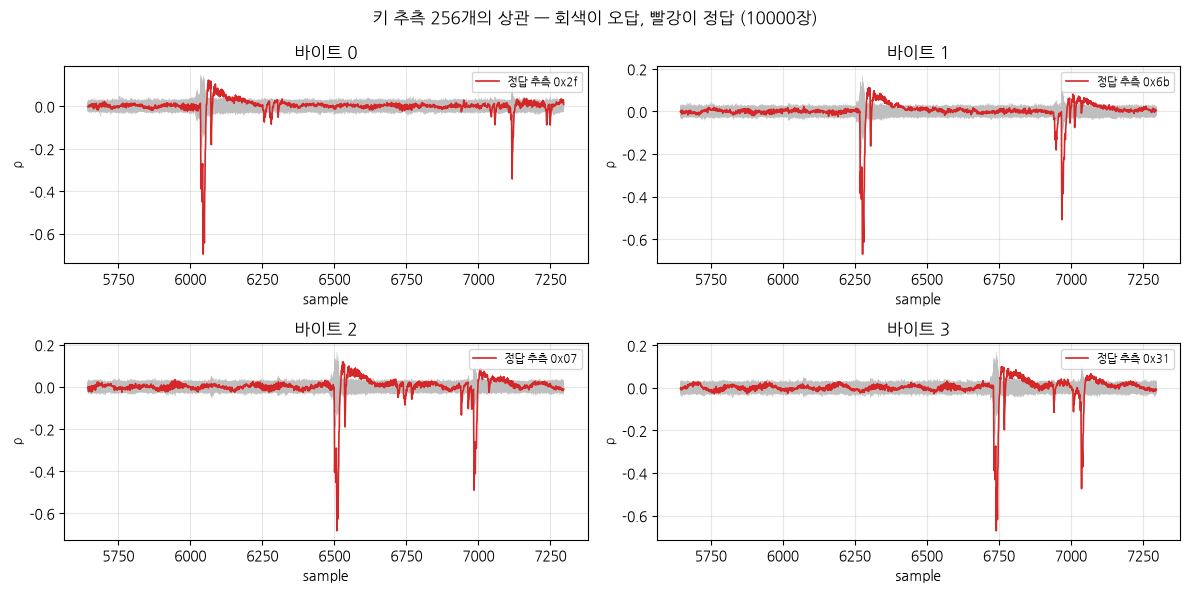

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, b in zip(axes.ravel(), (0, 1, 2, 3)):
    for g in range(256):
        ax.plot(range(LO, HI), corr[b, g], lw=0.3, color="0.75")
    ax.plot(range(LO, HI), corr[b, TRUE_KEY[b]], lw=1.2, color="C3",
            label="정답 추측 0x%02x" % TRUE_KEY[b])
    ax.set_title("바이트 %d" % b); ax.set_xlabel("sample"); ax.set_ylabel("ρ")
    ax.legend(loc="upper right", fontsize=8); ax.grid(True, alpha=0.3)
fig.suptitle("키 추측 256개의 상관 — 회색이 오답, 빨강이 정답 (%d장)" % n)
fig.tight_layout(); plt.show()

---
## 4. 몇 장이면 되는가

CPA 의 실용성은 "얼마나 적은 트레이스로 성공하는가" 로 잰다.
장수를 늘려 가며 **몇 바이트가 맞는지**를 본다.

In [7]:
def attack(m):
    c = Cpa(nc=256, kind=Cpa.IntermediateKind.Xor)
    c.fit_u(np.ascontiguousarray(seg[:m]), labels[:m])
    a = np.nanmax(np.abs(c.get_correlation(models)), axis=2)
    return a.argmax(axis=1).astype(np.uint8)

counts = [50, 100, 200, 500, 1000, 2000, 5000, n]
res = []
print("장수     맞은 바이트")
for m in counts:
    r = attack(m)
    hit = int((r == TRUE_KEY).sum())
    res.append(hit)
    print("%6d      %2d / 16   %s" % (m, hit, "★ 전부 복구" if hit == 16 else ""))

장수     맞은 바이트
    50       8 / 16   
   100      16 / 16   ★ 전부 복구


   200      16 / 16   ★ 전부 복구
   500      16 / 16   ★ 전부 복구
  1000      16 / 16   ★ 전부 복구


  2000      16 / 16   ★ 전부 복구
  5000      16 / 16   ★ 전부 복구
 10000      16 / 16   ★ 전부 복구


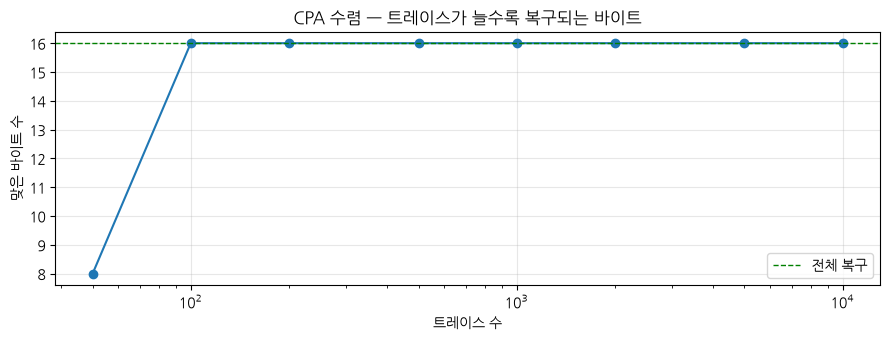

In [8]:
plt.figure(figsize=(9, 3.5))
plt.plot(counts, res, "o-")
plt.axhline(16, color="g", ls="--", lw=1, label="전체 복구")
plt.xscale("log"); plt.xlabel("트레이스 수"); plt.ylabel("맞은 바이트 수")
plt.title("CPA 수렴 — 트레이스가 늘수록 복구되는 바이트")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

---
## 5. 누설 모델을 바꾸면

해밍 가중치는 **가정**이다. 타겟이 실제로 그렇게 새지 않으면 공격이 약해진다.
다른 모델과 비교해 이 가정이 이 타겟에 맞는지 확인한다.

| 모델 | 뜻 |
|------|-----|
| `HW(SBOX[v])` | S-box 출력의 1비트 개수 — 레지스터에 값이 실릴 때의 전력 |
| `SBOX[v] & 1` | 최하위 비트 하나만 — 정보가 적다 |
| `HW(v)` | S-box **입력**의 1비트 개수 — 비선형을 안 거쳐 추측 구분이 어렵다 |

In [9]:
def attack_model(model_1d, m=2000):
    mm = np.broadcast_to(np.asarray(model_1d, dtype=np.float64)[None, :, None],
                         (NV, 256, seg.shape[1])).copy()
    c = Cpa(nc=256, kind=Cpa.IntermediateKind.Xor)
    c.fit_u(np.ascontiguousarray(seg[:m]), labels[:m])
    a = np.nanmax(np.abs(c.get_correlation(mm)), axis=2)
    return int((a.argmax(axis=1).astype(np.uint8) == TRUE_KEY).sum()), a.max()

v = np.arange(256)
for name, mdl in (("HW(SBOX[v])  (기본)", HW[SBOX[v]]),
                  ("SBOX[v] 의 LSB", (SBOX[v] & 1)),
                  ("HW(v)  S-box 입력", HW[v])):
    hit, mx = attack_model(mdl)
    print("  %-22s → 2000장에서 %2d/16 바이트, 최대 |ρ| %.4f" % (name, hit, mx))

  HW(SBOX[v])  (기본)      → 2000장에서 16/16 바이트, 최대 |ρ| 0.7037
  SBOX[v] 의 LSB          → 2000장에서 16/16 바이트, 최대 |ρ| 0.2476
  HW(v)  S-box 입력        → 2000장에서  9/16 바이트, 최대 |ρ| 0.6704


---
## 6. 요약

| 항목 | 내용 |
|------|------|
| 목적 | **프로파일링 없이** 키를 복구한다 |
| API | `Cpa(nc, kind)` → `fit_u(traces, labels)` → `get_correlation(models)` |
| `labels` | `(n, nv)` `uint16` — **알려진 값(평문)**. 키가 아니다 |
| `models` | `(nv, nc, ns)` `float64` — 중간값별 예측 누설 |
| `kind` | `Xor` (중간값 = label ^ guess) 또는 `Add` |
| 결과 | `(nv, nc, ns)` 상관. 바이트별 `argmax` 가 복구한 키 |

### 실패 시 점검

1. 라벨에 **키**를 넣으면 안 된다. 공격자는 키를 모른다 — 평문을 넣는다.
2. `models` 의 축 순서가 `(nv, nc, ns)` 인지 확인한다.
3. 아무 바이트도 안 맞는다 → 누설 모델이 타겟과 안 맞거나, 분석 구간에 해당 중간값이
   없다. 1.0 SNR 로 누설 위치부터 확인한다.
4. 일부만 맞는다 → 트레이스를 늘린다. §4 의 수렴 곡선을 참고한다.

다음: `4.0.LDAClassifier.ipynb` — 타겟을 미리 프로파일링하면 얼마나 강해지는가.